# Lesson 03 - Training craft: initialisation, activations, optimisers, LR schedules,

batch norm, dropout, and overfitting. All in the NumPy MLP from lesson 02.

Questions this lesson answers
-----------------------------
* Why do deep nets refuse to train with a naive initialisation? (Signal propagation.)
* Why did ReLU replace sigmoid? (Vanishing derivatives, sigma' <= 1/4.)
* SGD vs momentum vs Adam: what does each actually do to the trajectory?
* Do learning-rate schedules matter?
* What does batch norm buy you in a deep network?
* How do I recognise and fight overfitting (weight decay, dropout, early stopping)?

Script version:  python lessons/03_training_craft/lesson.py

## Lesson 03 - Training craft

📄 [`lessons/03_training_craft/lesson.py`](../lessons/03_training_craft/lesson.py) · 📓 [`notebooks/03_training_craft.ipynb`](03_training_craft.ipynb)

### 1. Initialisation and signal propagation

For $z=\sum_{i=1}^{n}w_i h_i$ with independent zero-mean weights,
$\operatorname{Var}z = n\,\operatorname{Var}w\;\mathbb E[h^2]$. To keep the scale constant from
layer to layer, we need

* **Xavier/LeCun** (tanh, which is roughly linear near 0): $\operatorname{Var}w = 1/n$,
* **He/Kaiming** (ReLU, which zeroes half its inputs, so $\mathbb E[h^2]=\tfrac12\operatorname{Var}z$): $\operatorname{Var}w = 2/n$.

With weights of size 0.01 the activations shrink by about $0.01\sqrt{256}\approx0.16$ per layer
and vanish. The gradients are then about $10^{-7}$, so nothing learns. With ReLU + Xavier the signal
decays slowly; with ReLU + He it stays at order 1.

<p align="center"><img src="../docs/lesson03/init_signal_propagation.png" width="90%"></p>

### 2. Activations

Since $\sigma'(z)\le 1/4$, every sigmoid layer multiplies the backward signal by at most 1/4.
Six layers therefore attenuate it by up to $4^{-6}\approx 2\times10^{-4}$. tanh ($\tanh'(0)=1$) and
ReLU ($\text{ReLU}'=1$ where active) do not have this problem.

<p align="center"><img src="../docs/lesson03/activations.png" width="50%"></p>

### 3. Optimisers

| method | update |
|---|---|
| SGD | $\theta\leftarrow\theta-\eta g$ |
| momentum | $v\leftarrow\mu v-\eta g,\;\theta\leftarrow\theta+v$ (a heavy ball: it accumulates speed along consistent directions and damps oscillations across a valley) |
| Adam | $m\leftarrow\beta_1m+(1-\beta_1)g,\;s\leftarrow\beta_2s+(1-\beta_2)g^2,\;\theta\leftarrow\theta-\eta\,\hat m/(\sqrt{\hat s}+\epsilon)$ with bias corrections $\hat m=m/(1-\beta_1^t)$, $\hat s=s/(1-\beta_2^t)$ |

The Rosenbrock function $f=(1-x)^2+100(y-x^2)^2$ is a curved, narrow valley. Plain GD needs a tiny
step to stay stable across the valley, so it crawls along it. Adam divides each coordinate's step
by its own gradient scale and reaches the minimum.

<p align="center"><img src="../docs/lesson03/optimisers_rosenbrock.png" width="48%"> <img src="../docs/lesson03/optimisers_mlp.png" width="46%"></p>

### 4. Learning-rate schedules

Step decay (÷10 at 50 % and 75 % of training), cosine decay
$\eta_t=\tfrac12\eta_0(1+\cos\pi t/T)$, and linear warm-up. On this small problem all schedules
end within a fraction of a percent of each other. That is an honest negative result: schedules
matter most for large models and long training runs.

<p align="center"><img src="../docs/lesson03/lr_schedules.png" width="90%"></p>

### 5. Batch normalisation

BN re-centres and re-scales each feature using batch statistics. This keeps the pre-activations
in the useful, non-saturated range of the sigmoid, whatever the previous layers do. At test time
it uses running averages. A 10-layer sigmoid network does not train at all without BN; with BN,
it does.

<p align="center"><img src="../docs/lesson03/batchnorm.png" width="50%"></p>

### 6. Overfitting, regularisation, early stopping

150 training points with **20 % flipped labels** and a network with 67 000 parameters. Without
regularisation the network memorises the noise: training accuracy approaches 100 % while the
validation loss climbs. The remedies:

* **weight decay**, $L+\frac\lambda2\lVert W\rVert^2$, which prefers small weights and therefore
  smooth functions;
* **dropout**, which trains an ensemble of thinned networks;
* **early stopping** at the minimum of the validation loss.

Note that the "training loss" plotted with weight decay includes the penalty term.

<p align="center"><img src="../docs/lesson03/overfitting.png" width="95%"></p>

**Results:**

*(see the results table in the README)*



In [1]:
%matplotlib inline
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # make `nnaz` importable
from nnaz.notebooks import show_new_figures

from __future__ import annotations
import sys
from pathlib import Path
import numpy as np
from nnaz.common import banner, save_gif, save_results, savefig, seed_everything, setup_matplotlib
from nnaz.data import spirals
from nnaz.mlp_numpy import MLP, SGD, Adam, Layer, Linear, lr_schedule, softmax_cross_entropy, train
LESSON = 3
plt = setup_matplotlib()

## 1. Initialisation: how the activation scale propagates through 10 layers

In [2]:
def init_part(rng):
    banner("1. Initialisation: how the activation scale propagates through 10 layers")
    depth, width = 10, 256
    X = rng.normal(size=(512, width))
    y = rng.integers(0, 10, 512)
    cases = [("tanh", "small"), ("tanh", "xavier"), ("relu", "xavier"), ("relu", "he")]
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
    out = {}
    for act, init in cases:
        net = MLP([width] * depth + [10], np.random.default_rng(0), act=act, init=init)
        h, stds = X, []
        for layer in net.layers:
            h = layer.forward(h)
            if not isinstance(layer, Linear):
                stds.append(h.std())
        _, d = softmax_cross_entropy(h, y)
        net.backward(d)
        gnorms = [np.linalg.norm(layer.grads["W"]) for layer in net.layers if isinstance(layer, Linear)][:-1]
        label = f"{act} / {init}"
        axs[0].semilogy(range(1, len(stds) + 1), stds, "o-", label=label)
        axs[1].semilogy(range(1, len(gnorms) + 1), gnorms, "o-", label=label)
        out[label] = {"act_std_last": float(stds[-1]), "grad_ratio_first_last": float(gnorms[0] / gnorms[-1])}
        print(f"  {label:15s} activation std layer1 {stds[0]:.2e} -> layer{len(stds)} {stds[-1]:.2e};"
              f"  |dW| layer1/layer{len(gnorms)} = {gnorms[0] / gnorms[-1]:.2e}")
    axs[0].set_xlabel("hidden layer"); axs[0].set_title("forward: std of activations")
    axs[1].set_xlabel("hidden layer"); axs[1].set_title(r"backward: $\|\partial L/\partial W\|$ per layer")
    axs[0].legend()
    savefig(fig, LESSON, "init_signal_propagation.png")
    return {"init": out}

## 2. Activation functions in a 6-layer network (same Adam settings)

In [3]:
def activation_part(rng, epochs):
    banner("2. Activation functions in a 6-layer network (same Adam settings)")
    X, y = spirals(600, rng)
    fig, ax = plt.subplots(figsize=(5.5, 3.8))
    out = {}
    for act, init in [("sigmoid", "xavier"), ("tanh", "xavier"), ("relu", "he")]:
        net = MLP([2] + [64] * 6 + [3], np.random.default_rng(0), act=act, init=init)
        h = train(net, X, y, epochs=epochs, lr=3e-3, rng=np.random.default_rng(0))
        ax.semilogy(h["loss"], label=act)
        out[act] = {"final_loss": h["loss"][-1], "train_acc": h["train_acc"][-1]}
        print(f"  {act:8s} final loss {h['loss'][-1]:.4f}  train acc {h['train_acc'][-1]:.3f}")
    ax.set_xlabel("epoch"); ax.set_ylabel("training loss"); ax.legend()
    ax.set_title("6 hidden layers: sigmoid learns slowest")
    savefig(fig, LESSON, "activations.png")
    return {"activations": out}

**Helper `_Point`**: Wrap a 2-vector as a 'layer' so the same optimiser classes can move it.

In [4]:
class _Point(Layer):
    """Wrap a 2-vector as a 'layer' so the same optimiser classes can move it."""

    def __init__(self, p):
        super().__init__()
        self.params["p"] = np.array(p, float)

In [5]:
def rosenbrock(p):
    x, y = p
    f = (1 - x) ** 2 + 100 * (y - x * x) ** 2
    g = np.array([-2 * (1 - x) - 400 * x * (y - x * x), 200 * (y - x * x)])
    return f, g

## 3. Optimisers: SGD vs momentum vs Adam

In [6]:
def optimiser_part(rng, epochs):
    banner("3. Optimisers: SGD vs momentum vs Adam")
    runs = {"GD  (lr 1e-3)": lambda P: SGD(P, 1e-3),
            "momentum 0.9 (lr 1e-4)": lambda P: SGD(P, 1e-4, 0.9),
            "Adam (lr 2e-2)": lambda P: Adam(P, 2e-2)}
    trajs, out = {}, {}
    for name, make in runs.items():
        pt = _Point([-1.2, 1.0])  # the classic starting point
        opt = make([(pt, "p")])
        path = [pt.params["p"].copy()]
        for _ in range(3000):
            f, pt.grads["p"] = rosenbrock(pt.params["p"])
            opt.step()
            path.append(pt.params["p"].copy())
        trajs[name] = np.array(path)
        f_end = rosenbrock(pt.params["p"])[0]
        out[name] = float(f_end)
        print(f"  Rosenbrock after 3000 steps, {name:24s}: f = {f_end:.2e}   (minimum 0 at (1,1))")

    xs, ys = np.meshgrid(np.linspace(-1.6, 1.6, 300), np.linspace(-0.6, 1.6, 300))
    F = (1 - xs) ** 2 + 100 * (ys - xs ** 2) ** 2
    fig, ax = plt.subplots(figsize=(6, 4.2))
    ax.contour(xs, ys, np.log10(F + 1e-3), levels=25, cmap="Greys", linewidths=0.6)
    for name, tr in trajs.items():
        ax.plot(tr[:, 0], tr[:, 1], lw=1.5, label=name)
    ax.plot(1, 1, "r*", ms=14)
    ax.set_title("Rosenbrock valley, 3000 steps from (-1.2, 1)"); ax.legend(fontsize=8)
    savefig(fig, LESSON, "optimisers_rosenbrock.png")

    # animated version (every 30th step)
    from matplotlib.animation import FuncAnimation

    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.contour(xs, ys, np.log10(F + 1e-3), levels=25, cmap="Greys", linewidths=0.6)
    ax.plot(1, 1, "r*", ms=12)
    lines = {n: ax.plot([], [], lw=1.5, label=n)[0] for n in trajs}
    ax.legend(fontsize=7, loc="lower right")
    ttl = ax.set_title("")

    def draw(k):
        for n, ln in lines.items():
            ln.set_data(trajs[n][: 30 * k + 1, 0], trajs[n][: 30 * k + 1, 1])
        ttl.set_text(f"step {30 * k}")
        return list(lines.values())

    save_gif(FuncAnimation(fig, draw, frames=101), LESSON, "optimisers.gif", fps=12)

    # the same comparison on the spiral MLP
    X, y = spirals(600, rng)
    fig, ax = plt.subplots(figsize=(5.5, 3.8))
    for name, kw in [("SGD lr 0.1", dict(opt="sgd", lr=0.1)),
                     ("momentum lr 0.01", dict(opt="momentum", lr=0.01)),
                     ("momentum lr 0.1", dict(opt="momentum", lr=0.1)),
                     ("Adam lr 3e-3", dict(opt="adam", lr=3e-3))]:
        net = MLP([2, 64, 64, 3], np.random.default_rng(0))
        h = train(net, X, y, epochs=epochs, rng=np.random.default_rng(0), **kw)
        ax.semilogy(h["loss"], label=name)
        out["mlp " + name] = h["loss"][-1]
        print(f"  spiral MLP, {name:18s}: final loss {h['loss'][-1]:.4f}")
    ax.set_xlabel("epoch"); ax.set_ylabel("training loss"); ax.legend()
    savefig(fig, LESSON, "optimisers_mlp.png")
    return {"optimisers": out}

## 4. Learning-rate schedules (SGD + momentum 0.9, base lr 0.1)

In [7]:
def schedule_part(rng, epochs):
    banner("4. Learning-rate schedules (SGD + momentum 0.9, base lr 0.1)")
    X, y = spirals(600, rng, noise=0.3)
    Xte, yte = spirals(3000, rng, noise=0.3)
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
    out = {}
    for kind, warm in [("constant", 0), ("step", 0), ("cosine", 0), ("cosine", 5)]:
        label = kind + (" + warm-up" if warm else "")
        losses, accs = [], []
        for seed in range(3):  # average 3 seeds: single runs are noisy
            net = MLP([2, 64, 64, 3], np.random.default_rng(seed))
            h = train(net, X, y, Xte, yte, epochs=epochs, opt="momentum", lr=0.1, schedule=kind,
                      warmup=warm * 10, rng=np.random.default_rng(seed))
            losses.append(h["loss"]); accs.append(h["val_acc"][-1])
        n_b = int(np.ceil(len(X) / 64))
        axs[0].plot([lr_schedule(kind, 0.1, s, epochs * n_b, warm * 10) for s in range(epochs * n_b)],
                    label=label)
        axs[1].semilogy(np.mean(losses, 0), label=label)
        out[label] = {"final_train_loss": float(np.mean([l[-1] for l in losses])),
                      "test_acc": float(np.mean(accs))}
        print(f"  {label:20s} final train loss {out[label]['final_train_loss']:.4f}"
              f"  test acc {out[label]['test_acc']:.3f}  (mean of 3 seeds)")
    axs[0].set_xlabel("iteration"); axs[0].set_title("learning rate"); axs[0].legend()
    axs[1].set_xlabel("epoch"); axs[1].set_title("training loss (mean of 3 seeds)")
    savefig(fig, LESSON, "lr_schedules.png")
    return {"schedules": out}

## 5. Batch normalisation in a deep (10 hidden layers) sigmoid network

In [8]:
def batchnorm_part(rng, epochs):
    banner("5. Batch normalisation in a deep (10 hidden layers) sigmoid network")
    X, y = spirals(600, rng)
    fig, ax = plt.subplots(figsize=(5.5, 3.8))
    out = {}
    for bn in [False, True]:
        net = MLP([2] + [64] * 10 + [3], np.random.default_rng(0), act="sigmoid", init="xavier",
                  batchnorm=bn)
        h = train(net, X, y, epochs=epochs, opt="momentum", lr=0.05, rng=np.random.default_rng(0))
        name = "with BatchNorm" if bn else "plain"
        ax.plot(h["loss"], label=name)
        out[name] = {"final_loss": h["loss"][-1], "train_acc": h["train_acc"][-1]}
        print(f"  {name:15s} final loss {h['loss'][-1]:.4f}  train acc {h['train_acc'][-1]:.3f}")
    ax.set_xlabel("epoch"); ax.set_ylabel("training loss"); ax.legend()
    ax.set_title("10 sigmoid layers, SGD+momentum lr 0.05")
    savefig(fig, LESSON, "batchnorm.png")
    return {"batchnorm": out}

## 6. Overfitting: 150 training points with 20% flipped labels, a 2-256-256-3 network

In [9]:
def overfitting_part(rng, epochs):
    banner("6. Overfitting: 150 training points with 20% flipped labels, a 2-256-256-3 network")
    X, y = spirals(150, rng, noise=0.3)
    flip = rng.random(len(y)) < 0.2  # label noise: a big net will happily memorise it
    y[flip] = (y[flip] + rng.integers(1, 3, flip.sum())) % 3
    Xv, yv = spirals(3000, rng, noise=0.3)  # clean validation labels
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
    out = {}
    for name, kw in [("no regularisation", {}), ("weight decay 1e-3", dict(weight_decay=1e-3)),
                     ("dropout 0.3", dict(dropout=0.3)), ("dropout 0.3 + wd 1e-3", dict(dropout=0.3, weight_decay=1e-3))]:
        wd = kw.pop("weight_decay", 0.0)
        net = MLP([2, 256, 256, 3], np.random.default_rng(0), **kw)
        h = train(net, X, y, Xv, yv, epochs=epochs, lr=3e-3, batch=32, weight_decay=wd,
                  rng=np.random.default_rng(0))
        l, = axs[0].plot(h["loss"], lw=1)
        axs[0].plot(h["val_loss"], color=l.get_color(), ls="--", label=name)
        axs[1].plot(h["val_acc"], color=l.get_color(), label=name)
        best = int(np.argmin(h["val_loss"]))
        out[name] = {"train_acc": h["train_acc"][-1], "val_acc_final": h["val_acc"][-1],
                     "val_loss_final": h["val_loss"][-1], "best_epoch": best,
                     "val_acc_early_stop": h["val_acc"][best]}
        print(f"  {name:24s} train acc {h['train_acc'][-1]:.3f}  val acc {h['val_acc'][-1]:.3f}"
              f"  val loss {h['val_loss'][-1]:.3f} | early stopping at epoch {best}:"
              f" val acc {h['val_acc'][best]:.3f}")
    axs[0].set_ylim(0, 2); axs[0].set_xlabel("epoch")
    axs[0].set_title("train (solid) vs validation (dashed) loss"); axs[0].legend(fontsize=8)
    axs[1].set_xlabel("epoch"); axs[1].set_title("validation accuracy")
    savefig(fig, LESSON, "overfitting.png")
    return {"overfitting": out}

## Run the lesson

Set `quick = True` for a fast pass (fewer epochs; numbers will differ from the README).

In [10]:
quick = False

In [11]:
rng = seed_everything(3)

In [12]:
res = {}


1. Initialisation: how the activation scale propagates through 10 layers
  tanh / small    activation std layer1 1.56e-01 -> layer9 6.69e-08;  |dW| layer1/layer9 = 9.89e-01
  tanh / xavier   activation std layer1 6.27e-01 -> layer9 2.40e-01;  |dW| layer1/layer9 = 1.09e+00
  relu / xavier   activation std layer1 5.84e-01 -> layer9 4.88e-02;  |dW| layer1/layer9 = 7.86e-01


  relu / he       activation std layer1 8.26e-01 -> layer9 1.10e+00;  |dW| layer1/layer9 = 1.43e-01


  saved docs/lesson03/init_signal_propagation.png


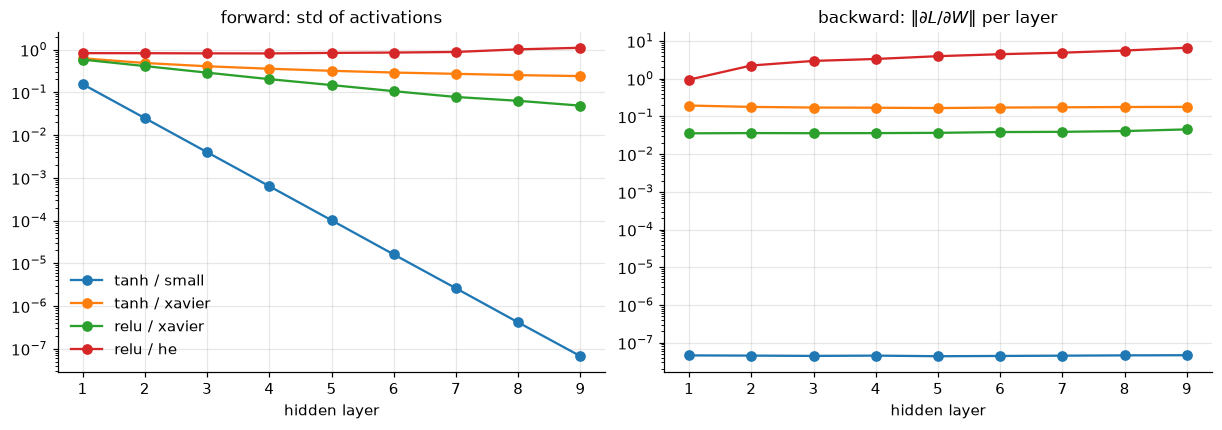

In [13]:
t0 = time.time()
res.update(init_part(rng))
show_new_figures(t0, LESSON)


2. Activation functions in a 6-layer network (same Adam settings)


  sigmoid  final loss 0.5343  train acc 0.798


  tanh     final loss 0.0002  train acc 1.000


  relu     final loss 0.0000  train acc 1.000


  saved docs/lesson03/activations.png


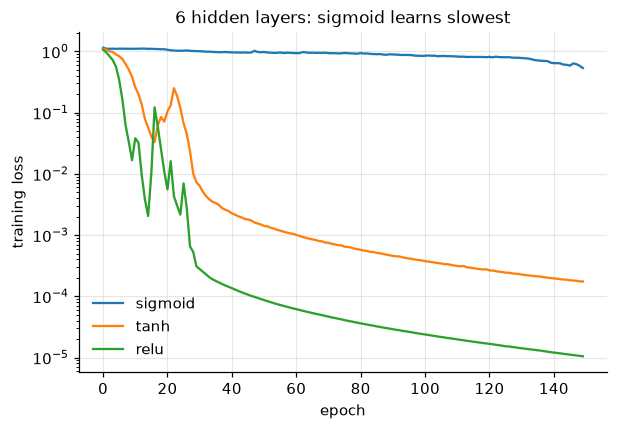

In [14]:
t0 = time.time()
res.update(activation_part(rng, 150 if not quick else 10))
show_new_figures(t0, LESSON)


3. Optimisers: SGD vs momentum vs Adam
  Rosenbrock after 3000 steps, GD  (lr 1e-3)           : f = 2.49e-02   (minimum 0 at (1,1))
  Rosenbrock after 3000 steps, momentum 0.9 (lr 1e-4)  : f = 2.37e-02   (minimum 0 at (1,1))
  Rosenbrock after 3000 steps, Adam (lr 2e-2)          : f = 2.84e-07   (minimum 0 at (1,1))


  saved docs/lesson03/optimisers_rosenbrock.png


  saved docs/lesson03/optimisers.gif


  spiral MLP, SGD lr 0.1        : final loss 0.0822


  spiral MLP, momentum lr 0.01  : final loss 0.0842


  spiral MLP, momentum lr 0.1   : final loss 0.0016


  spiral MLP, Adam lr 3e-3      : final loss 0.0041
  saved docs/lesson03/optimisers_mlp.png


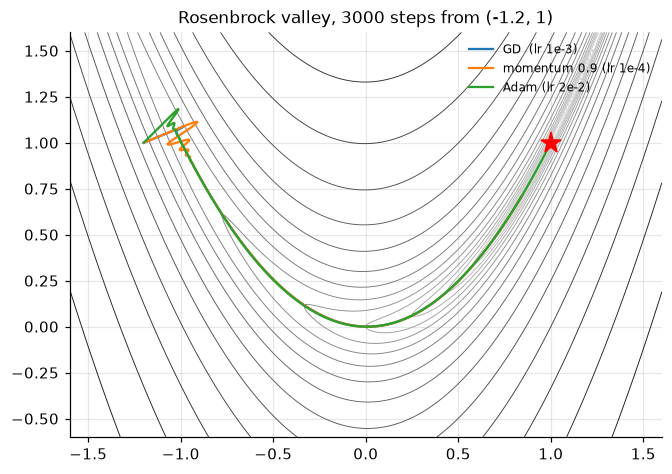

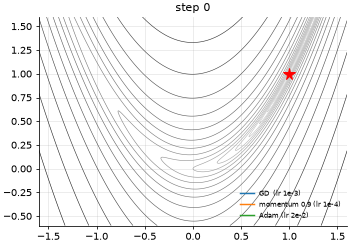

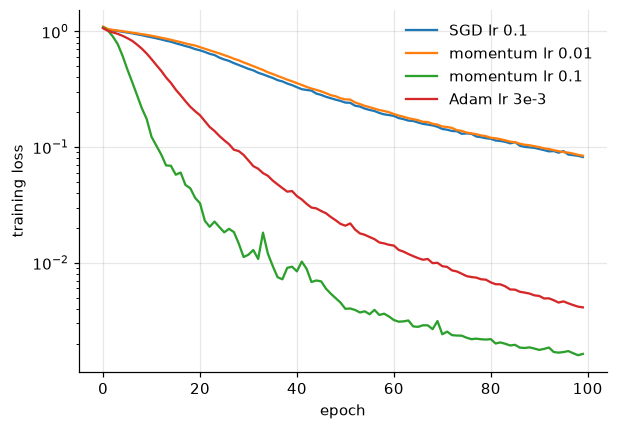

In [15]:
t0 = time.time()
res.update(optimiser_part(rng, 100 if not quick else 10))
show_new_figures(t0, LESSON)


4. Learning-rate schedules (SGD + momentum 0.9, base lr 0.1)


  constant             final train loss 0.0025  test acc 0.997  (mean of 3 seeds)


  step                 final train loss 0.0062  test acc 0.996  (mean of 3 seeds)


  cosine               final train loss 0.0070  test acc 0.996  (mean of 3 seeds)


  cosine + warm-up     final train loss 0.0065  test acc 0.996  (mean of 3 seeds)


  saved docs/lesson03/lr_schedules.png


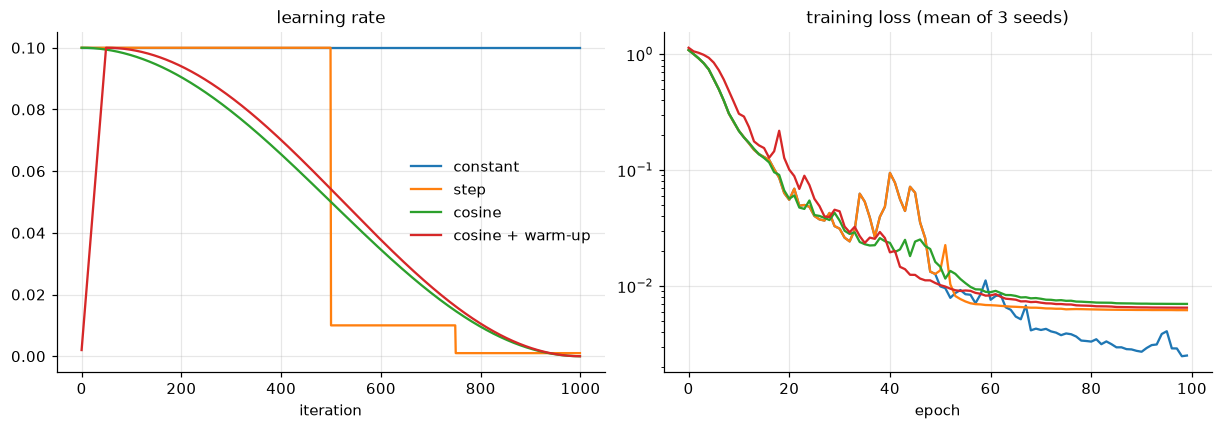

In [16]:
t0 = time.time()
res.update(schedule_part(rng, 100 if not quick else 10))
show_new_figures(t0, LESSON)


5. Batch normalisation in a deep (10 hidden layers) sigmoid network


  plain           final loss 1.1036  train acc 0.333


  with BatchNorm  final loss 0.2457  train acc 0.863
  saved docs/lesson03/batchnorm.png


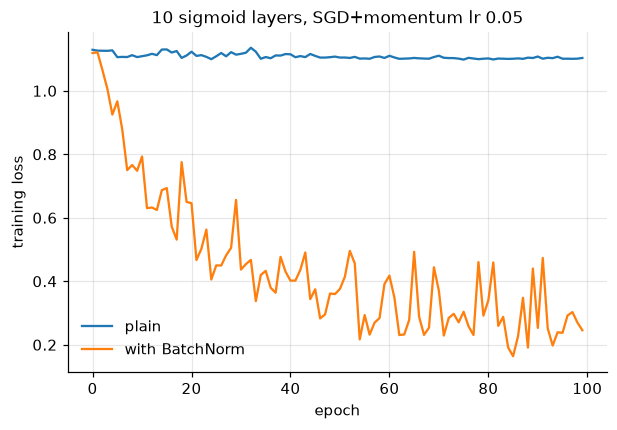

In [17]:
t0 = time.time()
res.update(batchnorm_part(rng, 100 if not quick else 10))
show_new_figures(t0, LESSON)


6. Overfitting: 150 training points with 20% flipped labels, a 2-256-256-3 network


  no regularisation        train acc 0.993  val acc 0.760  val loss 1.165 | early stopping at epoch 58: val acc 0.835


  weight decay 1e-3        train acc 0.940  val acc 0.797  val loss 0.542 | early stopping at epoch 122: val acc 0.832


  dropout 0.3              train acc 0.953  val acc 0.795  val loss 0.605 | early stopping at epoch 197: val acc 0.859


  dropout 0.3 + wd 1e-3    train acc 0.913  val acc 0.819  val loss 0.452 | early stopping at epoch 199: val acc 0.892


  saved docs/lesson03/overfitting.png


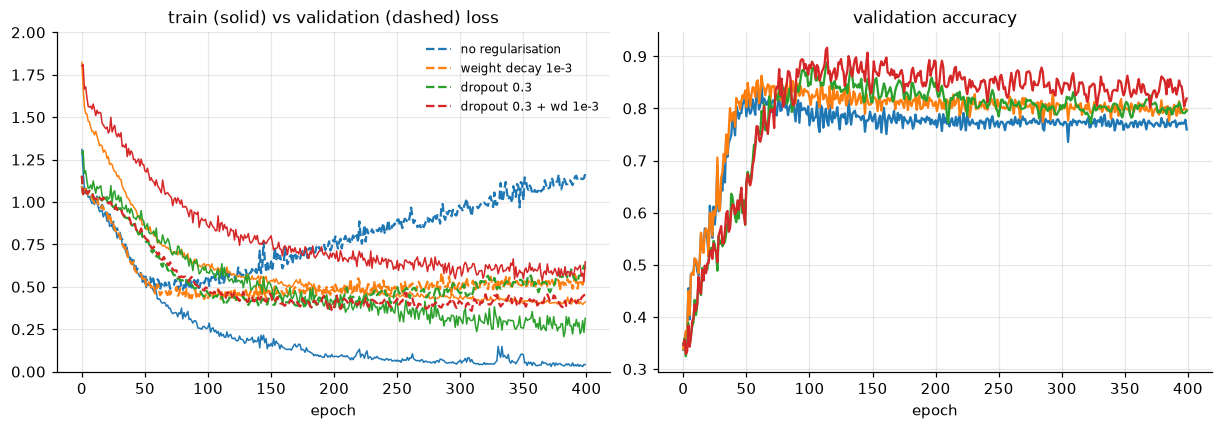

In [18]:
t0 = time.time()
res.update(overfitting_part(rng, 400 if not quick else 20))
show_new_figures(t0, LESSON)

In [19]:
_ = save_results(LESSON, res)

In [20]:
res  # all numbers of this run

{'init': {'tanh / small': {'act_std_last': 6.692056290574201e-08,
   'grad_ratio_first_last': 0.9893768321135159},
  'tanh / xavier': {'act_std_last': 0.24040676710808587,
   'grad_ratio_first_last': 1.0853213942541933},
  'relu / xavier': {'act_std_last': 0.04881704403591801,
   'grad_ratio_first_last': 0.7864811836334211},
  'relu / he': {'act_std_last': 1.1046036120089584,
   'grad_ratio_first_last': 0.14273203514572286}},
 'activations': {'sigmoid': {'final_loss': np.float64(0.534326937183875),
   'train_acc': np.float64(0.7983333333333333)},
  'tanh': {'final_loss': np.float64(0.00017474119155900852),
   'train_acc': np.float64(1.0)},
  'relu': {'final_loss': np.float64(1.0516136957081048e-05),
   'train_acc': np.float64(1.0)}},
 'optimisers': {'GD  (lr 1e-3)': 0.024863343078694304,
  'momentum 0.9 (lr 1e-4)': 0.02371051191342789,
  'Adam (lr 2e-2)': 2.836964102516879e-07,
  'mlp SGD lr 0.1': np.float64(0.08215858712159477),
  'mlp momentum lr 0.01': np.float64(0.08422403448315006